    This model contains 4 set of diffrenentional eqiation  to determine the  NEURAL DYNAMICS OF THE SYSTEM 
Those are as follows
1.  $$ C_m \frac{dV}{dt} = \underbrace{\bar{g}_{Na} m^3(V)h(V)( E_{Na} - V)}_{\mathrm{Ion_{Na}^+} } + \underbrace{\bar{g}_{K} n (E_{K} - V)}_{\mathrm{Ion_{K}^+}} + \underbrace{\bar{g}_{L}(E_L - V)}_{\mathrm{Ion_{Leak}}}$$
    
    * **$C_m \frac{dV}{dt}$** : The capacitive current (change in voltage)
    *  ___It discribe change in membrane voltage driven by ionic current flowing through the membrane___
------  
$$
\begin{cases}
2.  \frac{dm}{dt} = \alpha_{m}(V)(1-m)-\beta_{m}(V)_{m} \\
3.  \frac{dh}{dt} = \alpha_{h}(V)(1-h)-\beta_{h}(V)_{h} \\
4.  \frac{dn}{dt} = \alpha_{n}(V)(1-n)-\beta_{n}(V)_{n}
\end{cases}
$$

* The other three equation monitor the praportion of open ion channels which them selves depend on voltage  creating an feedback loop
------

### Imports

In [1]:
using DifferentialEquations, Plots

### Defining the constant

In [ ]:

# Voltage-dependent rate functions for the gating variables
# V is in millivolts (mV). These specific forms are tuned for a resting potential around -65mV.

α_m(V) = 0.1 * (V + 40.0) / (1.0 - exp(-(V + 40.0) / 10.0))
β_m(V) = 4.0 * exp(-(V + 65.0) / 18.0)

α_h(V) = 0.07 * exp(-(V + 65.0) / 20.0)
β_h(V) = 1.0 / (1.0 + exp(-(V + 35.0) / 10.0))

α_n(V) = 0.01 * (V + 55.0) / (1.0 - exp(-(V + 55.0) / 10.0))
β_n(V) = 0.125 * exp(-(V + 65.0) / 80.0)


β_n (generic function with 1 method)

In [3]:
function hodgkin_huxley!(du, u, p, t)
    V, m, h, n = u
    I_ext, g_Na, g_K, g_L, E_Na, E_K, E_L, C = p

    # 1. Calculate ionic currents
    I_Na = g_Na * (m^3) * h * (V - E_Na)
    I_K  = g_K * (n^4) * (V - E_K)
    I_L  = g_L * (V - E_L)

    # 2. Membrane potential differential equation
    du[1] = (I_ext - I_Na - I_K - I_L) / C

    # 3. Gating variable differential equations (dx/dt = α(1-x) - βx)
    du[2] = α_m(V) * (1 - m) - β_m(V) * m
    du[3] = α_h(V) * (1 - h) - β_h(V) * h
    du[4] = α_n(V) * (1 - n) - β_n(V) * n
end

hodgkin_huxley! (generic function with 1 method)

In [4]:
# Standard HH Parameters
p = (
    I_ext = 10,  # External current (μA/cm²) - Try changing this to 2.0 or 20.0!
    g_Na  = 120.0, # Max Sodium conductance (mS/cm²)
    g_K   = 36.0,  # Max Potassium conductance (mS/cm²)
    g_L   = 0.3,   # Leak conductance (mS/cm²)
    E_Na  = 50.0,  # Sodium reversal potential (mV)
    E_K   = -77.0, # Potassium reversal potential (mV)
    E_L   = -54.4, # Leak reversal potential (mV)
    C     = 1.0    # Membrane capacitance (μF/cm²)
)

# Initial conditions: [V, m, h, n] roughly at resting state
u0 = [-65.0, 0.05, 0.6, 0.32]
tspan = (0.0, 50.0) # Simulate for 50 milliseconds

# Solve the system
prob = ODEProblem(hodgkin_huxley!, u0, tspan, p)
sol = solve(prob, Tsit5(), reltol=1e-6, abstol=1e-6)

retcode: Success
Interpolation: specialized 4th order "free" interpolation
t: 503-element Vector{Float64}:
  0.0
  0.03933187799902175
  0.09065999045313736
  0.1539420417928659
  0.23012502654696743
  0.3191021578078171
  0.42102075775876974
  0.5354162590368663
  0.6617463495254029
  0.7991895282871246
  0.9471453874079221
  1.1059575852137464
  1.2814952479353132
  ⋮
 48.88330580277952
 48.9506111657139
 49.02224923022025
 49.099087286607975
 49.182150850008064
 49.27268831627593
 49.37226789196844
 49.48291766697757
 49.60737404921196
 49.74943517912726
 49.913653132132254
 50.0
u: 503-element Vector{Vector{Float64}}:
 [-65.0, 0.05, 0.6, 0.32]
 [-64.62344814725988, 0.050630899903509906, 0.5999514500398262, 0.320004198391742]
 [-64.14428473066752, 0.0518334745777869, 0.5997966980428404, 0.3200718499965336]
 [-63.57031230285135, 0.053793736041554636, 0.5994651230817762, 0.3202501970491029]
 [-62.90013436957967, 0.05670404995146883, 0.5988619117866282, 0.3206008729139377]
 [-62.140248

In [5]:
size(sol[1, :])

(503,)

In [6]:
sol[2]

4-element Vector{Float64}:
 -64.62344814725988
   0.050630899903509906
   0.5999514500398262
   0.320004198391742

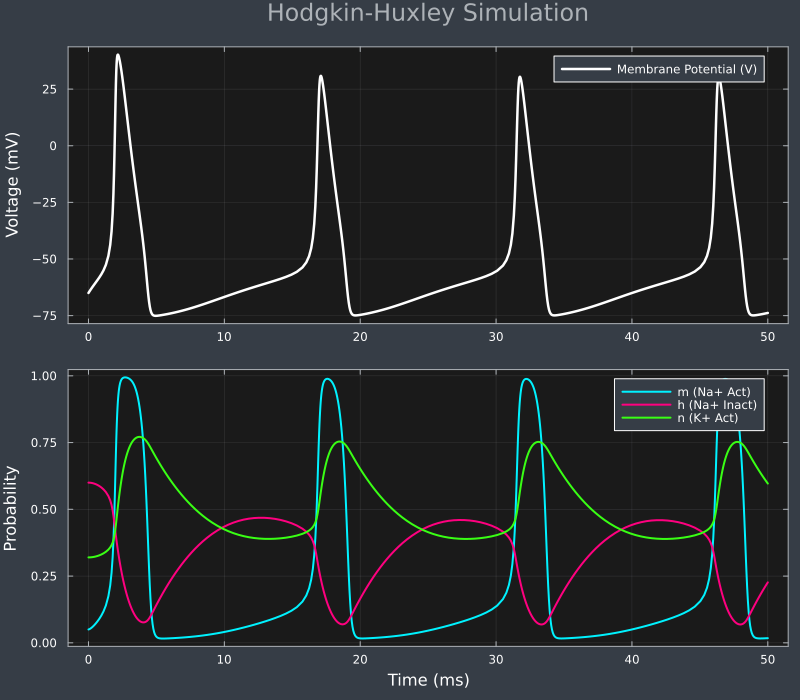

In [7]:


# Choose a dark theme for that "Neon" look
theme(:dark) 

# Define the Neon Color Palette from your image
neon_cyan = "#00f2ff"   # m_inf / tau_m
neon_pink = "#ff007f"   # h_inf / tau_h
neon_green = "#39ff14"  # n_inf / tau_n
background_charcoal = "#1a1a1a"

# Plotting the Voltage (Top Plot)
p1 = plot(sol.t, sol[1,:], 
          label="Membrane Potential (V)", 
          ylabel="Voltage (mV)", 
          color=:white, 
          linewidth=2.5,
          background_color_inside = background_charcoal,
          framestyle = :box)

# Plotting the Gating Variables (Bottom Plot)
p2 = plot(sol.t, sol[2,:], 
          label="m (Na+ Act)", 
          color=neon_cyan, 
          linewidth=2,
          background_color_inside = background_charcoal)

plot!(p2, sol.t, sol[3,:], 
      label="h (Na+ Inact)", 
      color=neon_pink, 
      linewidth=2)

plot!(p2, sol.t, sol[4,:], 
      label="n (K+ Act)", 
      color=neon_green, 
      linewidth=2,
      xlabel="Time (ms)", 
      ylabel="Probability",
      framestyle = :box)

# Combine plots with a clean layout
plot(p1, p2, layout=(2,1), size=(800, 700), plot_title="Hodgkin-Huxley Simulation")

### F_I curve

In [8]:
I_range = collect(0.0:0.5:25)
all_sol = []

for i in I_range
          # Standard HH Parameters
          p = (
              I_ext = i,  # External current (μA/cm²) - Try changing this to 2.0 or 20.0!
              g_Na  = 120.0, # Max Sodium conductance (mS/cm²)
              g_K   = 36.0,  # Max Potassium conductance (mS/cm²)
              g_L   = 0.3,   # Leak conductance (mS/cm²)
              E_Na  = 50.0,  # Sodium reversal potential (mV)
              E_K   = -77.0, # Potassium reversal potential (mV)
              E_L   = -54.4, # Leak reversal potential (mV)
              C     = 1.0    # Membrane capacitance (μF/cm²)
          )

          # Initial conditions: [V, m, h, n] roughly at resting state
          u0 = [-65.0, 0.05, 0.6, 0.32]
          tspan = (0.0, 50.0) # Simulate for 50 milliseconds

          # Solve the system
          prob = ODEProblem(hodgkin_huxley!, u0, tspan, p)
          sol = solve(prob, Tsit5(), reltol=1e-6, abstol=1e-6)
          push!(all_sol,sol)



          
end

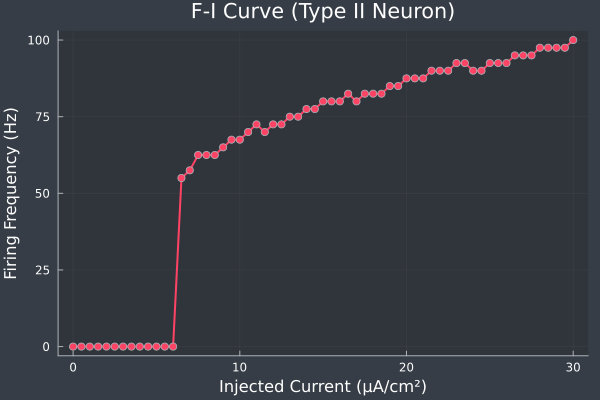

In [9]:
# 1. SETUP THE SWEEP
I_range = 0.0:0.5:30.0    
frequencies = zeros(length(I_range)) # Pre-allocation is faster in Julia

# 2. THE OUTER LOOP
for (idx, I_val) in enumerate(I_range)
    
    # Define your initial conditions (from your working sim)
    u0 = [-65.0, 0.05, 0.6, 0.32] # [V, m, h, n]
    tspan = (0.0, 500.0)
    
    # Update the external current parameter
    # Assuming p = [I_ext, gNa, gK, gL, ENa, EK, EL, C]
    p = [I_val, 120.0, 36.0, 0.3, 50.0, -77.0, -54.4, 1.0] 
    
    prob = ODEProblem(hodgkin_huxley!, u0, tspan, p)
    
    # Solve with a fixed 'saveat' so counting is consistent
    sol = solve(prob, Rosenbrock23(), saveat=0.1)
    
    # 3. SPIKE COUNTING LOGIC
    V = sol[1, :]
    time = sol.t
    spike_count = 0
    
    # We only count spikes after 100ms to ignore the 'startup' transient
    for i in 2:length(V)
        if time[i] > 100.0
            if V[i] >= 0.0 && V[i-1] < 0.0
                spike_count += 1
            end
        end
    end
    
    # 4. CALCULATE FREQUENCY (Hz)
    # Time window is 400ms = 0.4 seconds
    frequencies[idx] = spike_count / 0.4
end

# 5. FINAL PLOT
plot(I_range, frequencies, 
     title="F-I Curve (Type II Neuron)", 
     xlabel="Injected Current (μA/cm²)", 
     ylabel="Firing Frequency (Hz)",
     marker=:circle, 
     linewidth=2, 
     legend=false)

In [10]:
frequencies

61-element Vector{Float64}:
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   0.0
   ⋮
  90.0
  92.5
  92.5
  92.5
  95.0
  95.0
  95.0
  97.5
  97.5
  97.5
  97.5
 100.0

### ⚙️ Final Two Differential Equations
*(Standard 2-variable Hodgkin–Huxley reduction)*

Assume $m \approx m_\infty(V)$ and $h \approx h_\infty(V)$.
Then the reduced system becomes:

$$
\boxed{
C_m \frac{dV}{dt}
= - g_{Na} \, m_\infty(V)^3 \, h_\infty(V) \, (V - E_{Na})
- g_K \, n^4 (V - E_K)
- g_L (V - E_L)
+ I_{\text{ext}}
}
$$

$$
\boxed{
\frac{dn}{dt} = \frac{n_\infty(V) - n}{\tau_n(V)}
}
$$

---

### 🧩 Parameter Definitions

* $C_m$: membrane capacitance
* $g_{Na}, g_K, g_L$: maximum conductances
* $E_{Na}, E_K, E_L$: reversal potentials

And the voltage-dependent steady-state functions:

$$
m_\infty(V) = \frac{\alpha_m(V)}{\alpha_m(V) + \beta_m(V)}, \quad
h_\infty(V) = \frac{\alpha_h(V)}{\alpha_h(V) + \beta_h(V)}, \quad
n_\infty(V) = \frac{\alpha_n(V)}{\alpha_n(V) + \beta_n(V)}
$$

Time constant for $n$:

$$
\tau_n(V) = \frac{1}{\alpha_n(V) + \beta_n(V)}
$$

### 💾 Noise Generation and Data Export
This cell extracts the 4D state variables ($V, m, h, n$), calculates their variance, applies 0%, 10%, and 20% Additive White Gaussian Noise (AWGN), and saves them to separate directories.

In [ ]:
using DataFrames, CSV, Random, Statistics

# Set seed for reproducibility
Random.seed!(42)

# Generate noise function
function apply_noise(clean_data, noise_pct)
    if noise_pct == 0
        return clean_data
    end
    sigma = std(clean_data) * (noise_pct / 100.0)
    return clean_data .+ randn(length(clean_data)) .* sigma
end

# Extract 4D data from the solution
t_data = sol.t
V_clean = sol[1, :]
m_clean = sol[2, :]
h_clean = sol[3, :]
n_clean = sol[4, :]

out_base = "c:/Users/nirbh/Neural_Spiking_Dynamics/notebooks/1_data_generation"

# Apply noise and save
for p in [0, 10, 20]
    df = DataFrame(
        t = t_data,
        V = apply_noise(V_clean, p),
        m = apply_noise(m_clean, p),
        h = apply_noise(h_clean, p),
        n = apply_noise(n_clean, p)
    )
    folder_path = joinpath(out_base, "$(p)_noise")
    mkpath(folder_path) # Create directory if it doesn't exist
    CSV.write(joinpath(folder_path, "HH_4D_data.csv"), df)
    println("Saved $(p)% noise data to: $folder_path")
end
println("All data generated and saved successfully!")
